# 🇹🇳 Tunisian SFT Dataset — Cleaning Pipeline

**Input**: `categorized.csv` (12,575 rows)  
**Output**: `cleaned.csv` (deduplicated, dialect-verified, quality-filtered)

### Pipeline Order
1. Load & Setup
2. Deduplication (exact + near-duplicate instructions)
3. Very Short Entry Removal
4. Real Script Mismatch Detection
5. MSA Detection & Flagging
6. Spelling Normalization
7. Final Report & Export

## 1. Load & Setup

In [21]:
import pandas as pd
import numpy as np
import re
import unicodedata
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#52B788', '#9B5DE5', '#F77F00']

DATA_PATH   = r'C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\raw\categorized.csv'
OUTPUT_DIR  = r'C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data'

df_original = pd.read_csv(DATA_PATH)
df = df_original.copy()

print(f"Loaded {len(df):,} rows | {df['category'].nunique()} categories")
print(f"Columns: {list(df.columns)}")

# Cleaning log — tracks every step
cleaning_log = []

def log_step(step_name, df_before, df_after, note=''):
    removed = len(df_before) - len(df_after)
    cleaning_log.append({
        'step': step_name,
        'before': len(df_before),
        'after': len(df_after),
        'removed': removed,
        'pct_removed': removed / len(df_before) * 100,
        'note': note
    })
    print(f"[{step_name}] {len(df_before):,} → {len(df_after):,} "
          f"(removed {removed:,} = {removed/len(df_before)*100:.1f}%) {note}")
    return df_after

Loaded 12,575 rows | 9 categories
Columns: ['category', 'instruction', 'response']


## 2. Deduplication

**Strategy:**
- Exact row duplicates → keep first
- Same instruction + same response → keep first  
- Same instruction + different responses → keep them all

In [22]:
# ── Step 2a: Exact duplicate rows ─────────────────────────────────────────────
df_before = df.copy()
df = df.drop_duplicates()
df = log_step('exact_row_dedup', df_before, df, 'kept first of each exact duplicate')

# ── Step 2b: Same instruction + same response ─────────────────────────────────
df_before = df.copy()
df = df.drop_duplicates(subset=['instruction', 'response'])
df = log_step('instr_resp_dedup', df_before, df, 'kept first of identical (instr, resp) pairs')

# ── Step 2c: Same instruction, different responses → KEEP ALL ──────────────────
# SKIPPED — we keep all responses for the same instruction
# This allows multiple valid answer variants for the same question
print("[same_instr_multi_resp] Keeping all responses for same instruction — no dedup applied")

print(f"\nAfter all deduplication: {len(df):,} rows remain")

[exact_row_dedup] 12,575 → 11,869 (removed 706 = 5.6%) kept first of each exact duplicate
[instr_resp_dedup] 11,869 → 11,866 (removed 3 = 0.0%) kept first of identical (instr, resp) pairs
[same_instr_multi_resp] Keeping all responses for same instruction — no dedup applied

After all deduplication: 11,866 rows remain


In [23]:
# ── Inspect what was removed ───────────────────────────────────────────────────
# Find the originally duplicated instructions and show what we kept vs dropped
orig_dup_instrs = df_original['instruction'].value_counts()
orig_dup_instrs = orig_dup_instrs[orig_dup_instrs > 1].head(5).index.tolist()

print("Sample: what we kept from the most-duplicated instructions")
print("="*70)
for instr in orig_dup_instrs[:3]:
    kept = df[df['instruction'] == instr]
    original_count = df_original[df_original['instruction'] == instr].shape[0]
    if len(kept) > 0:
        print(f"\nInstruction [{original_count}x originally]:\n  {str(instr)[:80]}")
        print(f"Kept response ({len(kept.iloc[0]['response'])} chars):\n  {str(kept.iloc[0]['response'])[:200]}")

Sample: what we kept from the most-duplicated instructions

Instruction [10x originally]:
  شنيّة المَثَل إلّي يتقال كِي واحد يحب يستحفظ بصداقة عبد وهو ديما يغدر فيه ويجبد 
Kept response (187 chars):
  يقولوا 'حيّة في جيبك، ولا صاحب غدّار'. المعنى إنّو خطر العدو الواضح (كيما الحية) أهون ببرشة من خطر الصاحب اللي عامل فيها يحبك وهو يطعن فيك من تالي، خاطر الحية تحذر منها أما الصاحب تأمنله.

Instruction [9x originally]:
  شنيّة المَثَل إلّي يتقال كِي واحد يجي يطلب حاجة من إنسان هو بيده محتاج وموش لاقي
Kept response (120 chars):
  يقولوا 'العريان يكركر في المقطع'. يضربوه للي يستنجد بواحد أتعس منه ولا يطلب عون من إنسان عاجز، يعني الزوز في الهمّ عزاء.

Instruction [7x originally]:
  شنوّة يتقال لواحد ديما يلوم في غيره على فقره ولا قلة حيلته، وهو بيده موش قاعد يس
Kept response (212 chars):
  يقولوا 'اللِّي مَا تِتْعَبْ فِيهْ إيدِيكْ، مَا تِبْكِي عَلِيهْ عِينِيكْ'. يعني الحاجة اللي ما سهرتش عليها وما تعبتش باش تجيبها، ما عندكش الحق تحزن عليها كيف تضيع منك، خاطر الفائدة في الرزق اللي يجي با


## 3. Very Short Entry Removal

In [24]:
df['_instr_words'] = df['instruction'].fillna('').apply(lambda x: len(x.split()))
df['_resp_words']  = df['response'].fillna('').apply(lambda x: len(x.split()))

# ── Review very short entries before removing ─────────────────────────────────
very_short_resp  = df[df['_resp_words'] < 5]
very_short_instr = df[df['_instr_words'] < 3]

print(f"Very short responses (< 5 words): {len(very_short_resp)}")
print("\nSample short RESPONSES:")
for _, row in very_short_resp.sample(min(10, len(very_short_resp)), random_state=42).iterrows():
    print(f"  [{row['category']}] [{row['_resp_words']}w] instr: {str(row['instruction'])[:60]}")
    print(f"  → resp: {str(row['response'])}")
    print()

print(f"Very short instructions (< 3 words): {len(very_short_instr)}")
print("\nSample short INSTRUCTIONS:")
for _, row in very_short_instr.sample(min(10, len(very_short_instr)), random_state=42).iterrows():
    print(f"  [{row['category']}] [{row['_instr_words']}w] instr: {str(row['instruction'])}")
    print(f"  → resp: {str(row['response'])[:100]}")
    print()

Very short responses (< 5 words): 75

Sample short RESPONSES:
  [general_knowledge] [1w] instr: عندك 195 تفاحة وفرقت 65 منها على الجيران، قداش من تفاحة قعدت
  → resp: 130

  [general_knowledge] [3w] instr: في أنهي مركز يلعب بينس بيدي؟
  → resp: يلعب في الوسط.

  [general_knowledge] [1w] instr: عندك 6 ستيلوات وقسمتهم بالتساوي على 3 صناديق، قداش من ستيلو 
  → resp: 2

  [general_knowledge] [1w] instr: إذا كان خلطت ثلث العدد 18 مع ضعف العدد 6، قداش يولي المجموع؟
  → resp: 18

  [general_knowledge] [2w] instr: حاجة غريبة برشة، إذا كان تنطق اسمها بالصحيح يولي الاسم هذاكة
  → resp: كلمة 'غالط'

  [cultural_knowledge] [4w] instr: لو حابب يفهم الورد شكون من برا تونس، نقارنها بشنو؟
  → resp: الورد تشبه ماء الزهر.

  [general_knowledge] [2w] instr: واحد ماشي في الطريق عرضو واحد آخر، قالو: يا فلان، راهو بو ول
  → resp: الأب وابنه

  [general_knowledge] [1w] instr: عندك 5 كعبات قاطو وكليت 2، قداش قعدلك من كعبة؟
  → resp: 3

  [everyday_conversation] [4w] instr: شنوا لونك المفضل؟
  → resp: نحب اللو

## 5. MSA Detection & Flagging

**Goal**: Find responses written in Modern Standard Arabic (MSA) instead of Tunisian dialect.  
**Approach**: Dual scoring — penalize MSA markers, reward Tunisian markers. Responses with high MSA score and low Tunisian score get flagged.

⚠️ **This step flags, not auto-deletes.** You review and decide.

MSA-flagged responses: 9 (0.1%)


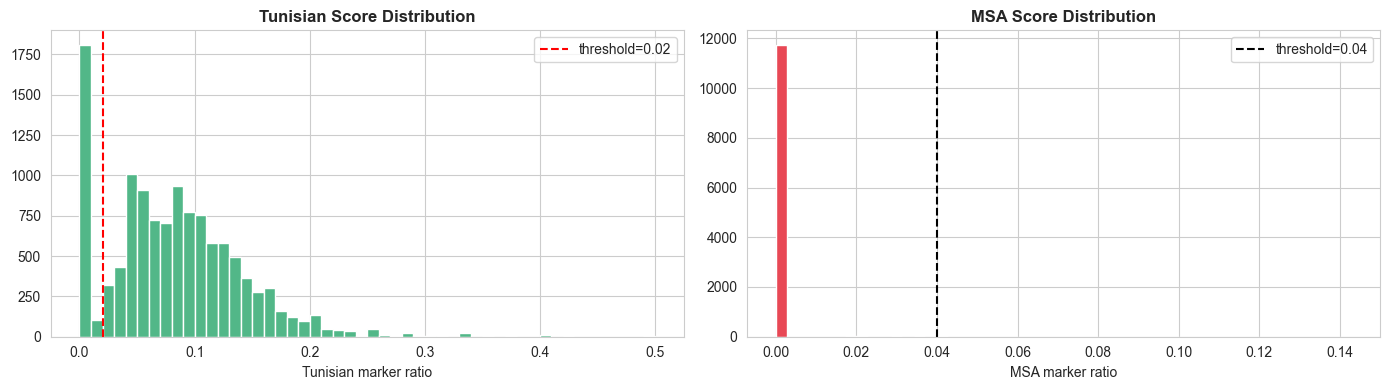

In [25]:
# ── Expanded Tunisian word list ────────────────────────────────────────────────
# Core Tunisian dialect markers — words that essentially never appear in MSA
TUN_MARKERS = {
    # Verbs & modals
    'باش', 'تنجم', 'ينجم', 'نجم', 'يلزم', 'لازمك', 'نحب', 'يحب',
    'نمشي', 'تمشي', 'يمشي', 'كان', 'مكانش', 'ماكانش',
    # Pronouns & demonstratives
    'هذا', 'هذي', 'هذم', 'هوكا', 'هاك', 'هاكي', 'هاكم',
    'أنا', 'أنتي', 'أنت', 'هوّ', 'هيّ', 'أحنا', 'أنتم',
    # Negation
    'موش', 'ماش', 'مانيش', 'ماهوش', 'ماهيش', 'ماعندوش', 'ماعنديش',
    'ما', 'ماش',
    # Connectors & discourse
    'اللي', 'كي', 'كِي', 'كيف', 'كيفاش', 'علاش', 'أما', 'وإلا',
    'يعني', 'خاطر', 'ديما', 'توا', 'توّا', 'بعدين', 'زعمة', 'يزي',
    # Quantity & degree
    'برشة', 'برشا', 'شوية', 'ياسر', 'قداش', 'بزاف',
    # Common nouns unique to dialect
    'متاع', 'متاعك', 'متاعو', 'متاعها', 'متاعنا', 'متاعكم', 'متاعهم',
    'حاجة', 'حوايج', 'بلاصة', 'ناس', 'واحد',
    # Interjections & fillers
    'ياخي', 'يا خي', 'آما', 'فما', 'وين', 'وقتاش', 'علاش',
    'بالله', 'والله', 'يزيك', 'صحيح',
    # Latin transliteration (Arabizi)
    'bahi', 'nheb', 'kifesh', 'barsha', 'moch', 'tawa', 'yezi',
    'wesh', 'alesh', 'manich', 'wين', 'haka',
}

# MSA markers — words/patterns that are almost never used in Tunisian dialect
# when speaking naturally (they appear in formal/written MSA)
MSA_MARKERS = {
    # MSA connectors
    'لذلك', 'وبالتالي', 'وعليه', 'إذ', 'حيث', 'كما', 'كذلك',
    'ولذا', 'وبما', 'إضافةً', 'فضلاً', 'علاوةً', 'بناءً',
    'وفقاً', 'طبقاً', 'استناداً', 'نظراً',
    # MSA formal verbs
    'يُعدّ', 'يُعتبر', 'يتضمن', 'يشمل', 'يهدف', 'يسعى',
    'يتمثل', 'يتضح', 'يتبين', 'يستوجب', 'يستلزم',
    'أسفر', 'أفضى', 'أسهم', 'أتاح', 'أبدى',
    # MSA formal nouns
    'الأمر', 'الشأن', 'المسألة', 'الوضع',
    'المجال', 'الميدان', 'القطاع', 'المستوى',
    # MSA demonstratives (dialect uses هذا/هذي but NOT هذه/ذلك/تلك heavily)
    'هذه', 'ذلك', 'تلك', 'هؤلاء', 'أولئك',
    # Formal phrases
    'في إطار', 'من أجل', 'على صعيد', 'في سياق', 'في ضوء',
    'تجدر الإشارة', 'تجدر الإشارة إلى', 'من الجدير',
}

def tokenize(text):
    if not isinstance(text, str): return []
    return re.findall(r'[\u0600-\u06FFa-zA-Z]+', text)

def score_dialect(text):
    """Returns (tunisian_score, msa_score, tun_hits, msa_hits)."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0, 0, [], []
    tokens = set(tokenize(text))
    tun_hits = tokens & TUN_MARKERS
    msa_hits = tokens & MSA_MARKERS
    # Also check phrase markers in full text
    for phrase in ['في إطار', 'على صعيد', 'في سياق', 'تجدر الإشارة',
                   'من الجدير', 'وعلى هذا الأساس']:
        if phrase in text:
            msa_hits = msa_hits | {phrase}
    n_words = max(len(tokenize(text)), 1)
    return len(tun_hits) / n_words, len(msa_hits) / n_words, list(tun_hits), list(msa_hits)

scores = df['response'].apply(score_dialect)
df['tun_score']  = scores.apply(lambda x: x[0])
df['msa_score']  = scores.apply(lambda x: x[1])
df['tun_hits']   = scores.apply(lambda x: x[2])
df['msa_hits']   = scores.apply(lambda x: x[3])

# ── MSA flag: high MSA score AND low Tunisian score ───────────────────────────
# These thresholds are calibrated for ~20-30 word responses
MSA_THRESHOLD = 0.04   # MSA marker ratio
TUN_THRESHOLD = 0.02   # Tunisian marker ratio

df['is_msa'] = (df['msa_score'] >= MSA_THRESHOLD) & (df['tun_score'] <= TUN_THRESHOLD)

print(f"MSA-flagged responses: {df['is_msa'].sum()} ({df['is_msa'].mean()*100:.1f}%)")

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['tun_score'], bins=50, color='#52B788', edgecolor='white')
axes[0].axvline(TUN_THRESHOLD, color='red', linestyle='--', label=f'threshold={TUN_THRESHOLD}')
axes[0].set_title('Tunisian Score Distribution', fontweight='bold')
axes[0].set_xlabel('Tunisian marker ratio'); axes[0].legend()

axes[1].hist(df['msa_score'], bins=50, color='#E84855', edgecolor='white')
axes[1].axvline(MSA_THRESHOLD, color='black', linestyle='--', label=f'threshold={MSA_THRESHOLD}')
axes[1].set_title('MSA Score Distribution', fontweight='bold')
axes[1].set_xlabel('MSA marker ratio'); axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
# ── Review flagged MSA entries ─────────────────────────────────────────────────
msa_flagged = df[df['is_msa']].sort_values('msa_score', ascending=False)

print(f"Reviewing top MSA-flagged entries ({len(msa_flagged)} total)")
print("="*70)
for _, row in msa_flagged.head(20).iterrows():
    print(f"[{row['category']}] MSA={row['msa_score']:.3f} TUN={row['tun_score']:.3f}")
    print(f"  MSA hits: {row['msa_hits']}")
    print(f"  instr: {str(row['instruction'])[:80]}")
    print(f"  resp:  {str(row['response'])[:200]}")
    print()

Reviewing top MSA-flagged entries (9 total)
[general_knowledge] MSA=0.143 TUN=0.000
  MSA hits: ['الميدان']
  instr: شكون هو بينس بيدي؟
  resp:  لاعب كورة مجري يلعب في وسط الميدان.

[cultural_knowledge] MSA=0.091 TUN=0.000
  MSA hits: ['حيث']
  instr: شنو الماكلات اللي الغزال عنصر أساسي فيها؟
  resp:  پلا الصيد النادر يتعمل في المناطق الجنوبية التونسية حيث يتصاد الغزال

[cultural_knowledge] MSA=0.053 TUN=0.000
  MSA hits: ['حيث']
  instr: شنوة أكبر مدينة في تونس؟
  resp:  تونس العاصمة هي أكبر مدينة في البلاد من حيث عدد السكان، وحسب إحصائيات 2021 يسكنوا فيها قريب 700 ألف نسمة (بالضبط 693,210).

[cultural_knowledge] MSA=0.053 TUN=0.000
  MSA hits: ['الأمر']
  instr: فلان قطع علاقته بالعايلة الكل وقال أنا نعيش وحدي وما نستحق لحد.
  resp:  يقولوا 'رجل ببراسه، ذهب في قرطاسه'. الرجل الذي يعتمد على نفسه فقط دون أهله ينتهي به الأمر وحيداً وبائساً.

[emotional_support] MSA=0.050 TUN=0.000
  MSA hits: ['حيث']
  instr: الديون غرقتني وما لقيتش حل، مانيش عارف كيفاش باش نخلص.
  resp:  ربي يرزقك من ح

MSA rate per category:
                          count      rate
category                                 
emotional_support             2  0.002345
cultural_knowledge            6  0.001771
general_knowledge             1  0.000775
advice_guidance               0  0.000000
everyday_conversation         0  0.000000
opinions_recommendations      0  0.000000
storytelling                  0  0.000000
student_life                  0  0.000000
task_oriented                 0  0.000000


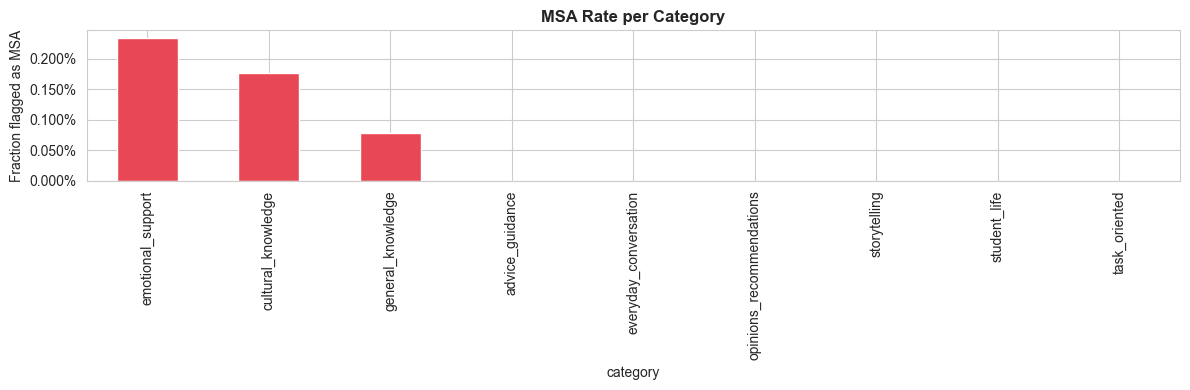

In [27]:
# ── MSA by category ───────────────────────────────────────────────────────────
cat_msa = df.groupby('category')['is_msa'].agg(['sum', 'mean']).sort_values('mean', ascending=False)
cat_msa.columns = ['count', 'rate']
print("MSA rate per category:")
print(cat_msa.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
cat_msa['rate'].plot(kind='bar', ax=ax, color='#E84855')
ax.set_title('MSA Rate per Category', fontweight='bold')
ax.set_ylabel('Fraction flagged as MSA')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

In [28]:
# ── Decision: separate MSA from clean ─────────────────────────────────────────
# We do NOT auto-delete MSA — we save it for manual review + possible rewriting
df_msa_flagged = df[df['is_msa']].copy()
df_before = df.copy()
df = df[~df['is_msa']].copy()

df = log_step('msa_removal', df_before, df, 'MSA-dominant responses removed')

df_msa_flagged.to_csv(f'{OUTPUT_DIR}\\msa_flagged_for_rewrite.csv', index=False)
print(f"\nSaved {len(df_msa_flagged)} MSA entries to msa_flagged_for_rewrite.csv")
print("→ Review these: some may just need a dialect rewrite, not full deletion.")

[msa_removal] 11,866 → 11,857 (removed 9 = 0.1%) MSA-dominant responses removed

Saved 9 MSA entries to msa_flagged_for_rewrite.csv
→ Review these: some may just need a dialect rewrite, not full deletion.


## 7. Final Report & Export

CLEANING PIPELINE SUMMARY
Step                            Before   After  Removed      %
-----------------------------------------------------------------
exact_row_dedup                 12,575  11,869      706   5.6%
instr_resp_dedup                11,869  11,866        3   0.0%
msa_removal                     11,866  11,857        9   0.1%
-----------------------------------------------------------------
TOTAL                           12,575  11,857      718   5.7%

Final category distribution:
                          before  after  removed  pct_kept
category                                                  
advice_guidance             3212   2943      269      91.6
cultural_knowledge          3509   3382      127      96.4
emotional_support            855    851        4      99.5
everyday_conversation        795    753       42      94.7
general_knowledge           1316   1289       27      97.9
opinions_recommendations     533    495       38      92.9
storytelling             

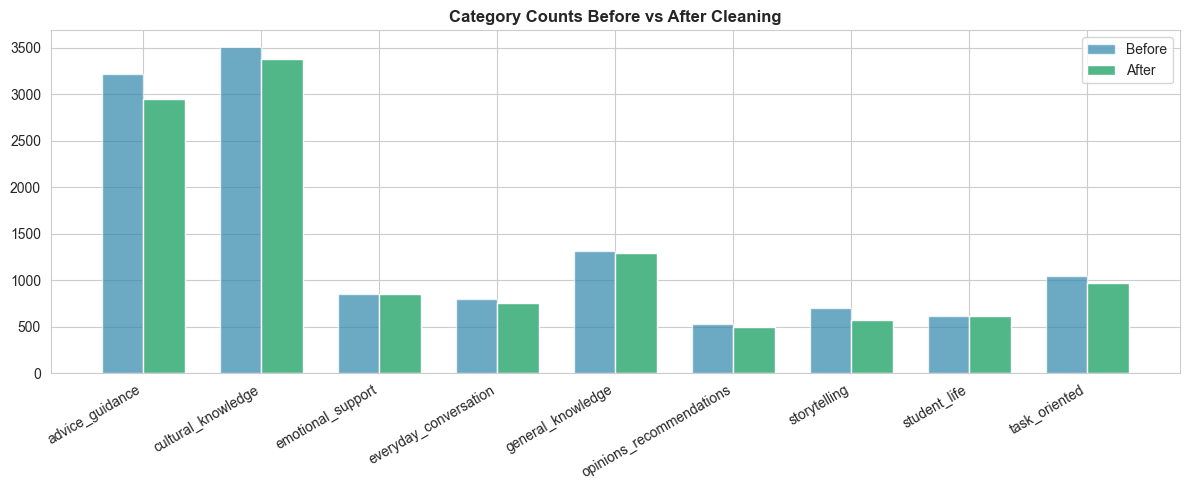

In [29]:
# ── Drop helper columns before export ─────────────────────────────────────────
helper_cols = ['_instr_words', '_resp_words', 'instr_script_v2', 'resp_script_v2',
               'tun_score', 'msa_score', 'tun_hits', 'msa_hits', 'is_msa']
df_final = df.drop(columns=[c for c in helper_cols if c in df.columns])

# ── Cleaning log summary ───────────────────────────────────────────────────────
print("="*65)
print("CLEANING PIPELINE SUMMARY")
print("="*65)
print(f"{'Step':<30} {'Before':>7} {'After':>7} {'Removed':>8} {'%':>6}")
print("-"*65)
for entry in cleaning_log:
    print(f"{entry['step']:<30} {entry['before']:>7,} {entry['after']:>7,} "
          f"{entry['removed']:>8,} {entry['pct_removed']:>5.1f}%")
print("-"*65)
original_count = len(df_original)
final_count    = len(df_final)
total_removed  = original_count - final_count
print(f"{'TOTAL':<30} {original_count:>7,} {final_count:>7,} "
      f"{total_removed:>8,} {total_removed/original_count*100:>5.1f}%")
print("="*65)

# ── Category distribution after cleaning ──────────────────────────────────────
print("\nFinal category distribution:")
cat_before = df_original['category'].value_counts()
cat_after  = df_final['category'].value_counts()
comparison = pd.DataFrame({'before': cat_before, 'after': cat_after})
comparison['removed'] = comparison['before'] - comparison['after']
comparison['pct_kept'] = (comparison['after'] / comparison['before'] * 100).round(1)
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison['before'], w, label='Before', color='#2E86AB', alpha=0.7)
ax.bar(x + w/2, comparison['after'],  w, label='After',  color='#52B788')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.set_title('Category Counts Before vs After Cleaning', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# ── Export ─────────────────────────────────────────────────────────────────────
cleaned_path = f'{OUTPUT_DIR}\\cleaned.csv'
df_final.to_csv(cleaned_path, index=False, encoding='utf-8-sig')

print(f"\n✅ Exported {len(df_final):,} clean rows to: cleaned.csv")
print(f"📋 MSA entries saved to:    msa_flagged_for_rewrite.csv ({len(df_msa_flagged):,} rows)")
print(f"📋 Short entries saved to:  removed_short.csv")
print()
print("Next steps:")
print("  1. Open msa_flagged_for_rewrite.csv — manually rewrite responses in Tunisian dialect")
print("  2. Merge rewritten entries back into cleaned.csv")
print("  3. Proceed to augmentation notebook for coverage gap filling")


✅ Exported 11,857 clean rows to: cleaned.csv
📋 MSA entries saved to:    msa_flagged_for_rewrite.csv (9 rows)
📋 Short entries saved to:  removed_short.csv

Next steps:
  1. Open msa_flagged_for_rewrite.csv — manually rewrite responses in Tunisian dialect
  2. Merge rewritten entries back into cleaned.csv
  3. Proceed to augmentation notebook for coverage gap filling
